Link Dashboard Tableau : https://public.tableau.com/app/profile/chandra.julian.adhiyasa/viz/DashboardAnalisisProfitE-Commerce/AnalisisProfitPenjualanE-Commerce

Link Dataset : https://www.kaggle.com/datasets/muhammadaammartufail/global-e-commerce-sales-and-customer-data?select=global_ecommerce_sales.csv

# I. Perkenalan

Milestone 2

Nama  : Chandra Julian Adhiyasa
Batch : CODA-RMT-016

Program ini dibuat untuk evaluasi phase 1.

# II. Identifikasi Masalah

Topik Permasalahan : 

Analisis Faktor-faktor yang mempengaruhi Profitablitas Penjualan E-Commerce Guna Optimasi Profit

Problem Statement menggunakan metode SMART :
- Specific : Menganalisis faktor-faktor yang mempengaruhi profit penjualan.
- Measurable : Meningkatkan profit yang lebih tinggi dari periode sebelumnya.
- Achievable : Meningkatkan profit dengan optimalisasi produk high-perform. Evaluasi strategi penjualan yang kurang perform.
- Relevant : Analisis dilakukan untuk mendukung pengambilan keputusan dalam bisnis guna meningkatkan efisiensi transaksi dan memaksimalkan faktor utama yang mempengaruhi profit.
- Time-bound : Peningkatan profit dapat dicapai dalam kurun waktu 6 bulan.

Latar Belakang :

Pengunaan dan pertumbuhan penjualan pada e-commerce telah berkembang cukup pesat dalam beberapa tahun terakhir yang membuat perusahaan harus melihat dan memahami faktor yang mempengaruhi profit perusahaan. Diperlukan analisis data historis guna membantu dalam mengambil keputusan strategis dalam optimasi penjualan produk dan wilayah penjualan.

Tujuan : 

Mengidentifikasi faktor-faktor yang mempengaruhi profit untuk memberikan strategi bisnis yang paling baik dan optimal

Penjabaran Masalah :

1. Produk apa saja yang memiliki profit tertinggi?
2. Region mana yang memiliki profit tertinggi?
3. Bagaimana tren profit perbulan?
4. Kategori produk mana menghasilkan keuntungan terbesar?
5. Bagaimana karakteristik profit perusahaan (mean, median, standar deviasi, skewness, dan kurtosis)?
6. Apa ada pengaruh yang signifikan variabel numerik terhadap profit yang didapat?

# III. Data Loading

## Import Library

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## Import / Read Dataset

In [25]:
# Import dataset
df = pd.read_csv('global_ecommerce_sales.csv')

## Menampilkan 5 data teratas pada dataset

In [26]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


## Menampilkan informasi struktur dataset

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


## Menampilkan data deskripsi statistik dari kolom numerik pada dataset

In [28]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
std,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593
min,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000


# IV. Data Cleaning

## Ubah tipe data pada kolom

In [29]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

## Hapus kolom yang kemungkinan tidak terpakai pada analisis

In [30]:
del df['Order_ID']
del df['Customer_Name']

## Menjadikan kolom Order_Date sebagai index

In [31]:
df = df.set_index('Order_Date')

# V. Analisis Dan Perhitungan

## 1. Produk dengan profit tertinggi

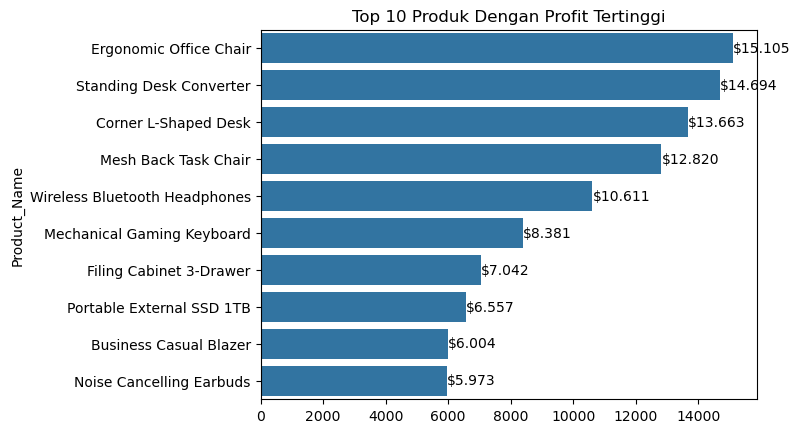

In [32]:
# inisiasi sebuiah variabel top_product untuk melihat total profit per product
top_product = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(10)

# mengatur bar chart menggunaakn seaborn untuk melihat visualisasi
ax = sns.barplot(x=top_product.values, y=top_product.index)

# Atur value label yang akan ditampilkan
# Melakukan looping pada setiap bar 
for container in ax.containers :
    value_label = [f'${value:,.0f}'.replace(',', '.') for value in container.datavalues] # Melaukan formatting pada value label
    ax.bar_label(container, labels=value_label) # Menampilkan Value Label apda setiap Bar

# Buat title pad chart
plt.title('Top 10 Produk Dengan Profit Tertinggi')
# Show Chart
plt.show()

### Insight

Dapat dilihat top 10 produk dengan profit tertinggi dimana produk 'Ergonomic Officer Chair' adalah produk dengan profit tertinggi sebesar $15.105

## 2. Profit Berdasarkan Region

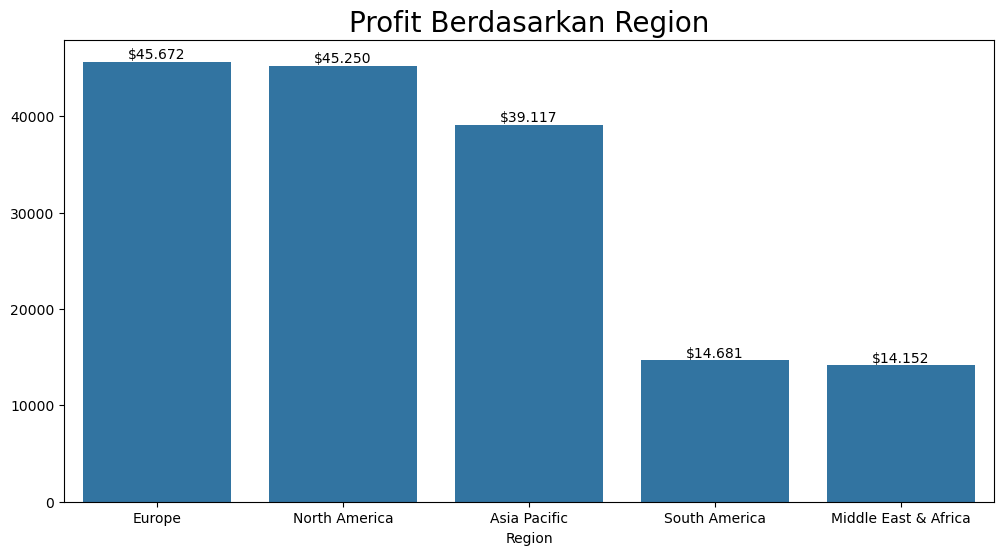

In [ ]:
# Inisiasi variabel untuk menyimpan hasil Total Profit dari setiap Region
profit_per_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Inisasi besaran kanvas visualisasi
plt.figure(figsize=(12,6))

# Menyimpan grafik bar chart ke dalam variabel baru
ax = sns.barplot(x=profit_per_region.index, y=profit_per_region.values)

# Melakukan looping pada setiap bar 
for container in ax.containers :
    value_label = [f'${value:,.0f}'.replace(',', '.') for value in container.datavalues] # Melaukan formatting pada value label
    ax.bar_label(container, labels=value_label) # Menampilkan Value Label apda setiap Bar

plt.title('Profit Berdasarkan Region', fontsize = 20) # Memberi judul Bar Chart
plt.show() # Tampilkan Bar Chart

### Insight

Region North America adalah region penghasil profit tertinggi yaitu 45.672 dolar, sementara yang terkecil adalah Middle East & Africa dengan 14.152 dollar

## 3. Tren Profitabilitas Per Bulan

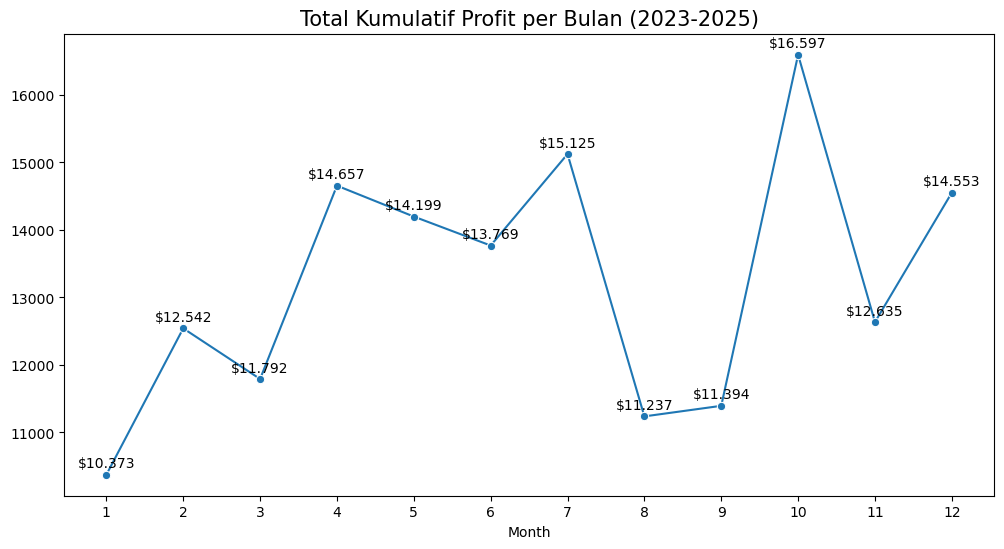

In [34]:
# Membuat kolom Baru yang menyimpan Bulan dari index (kolom Order Date)
df['Month'] = df.index.month

# Inisiasi Variabel yang akan mentotalkan Profit berdasarkan Bulan
monthly_profit = df.groupby('Month')['Profit'].sum()

# Inisasi besaran kanvas visualisasi
plt.figure(figsize=(12,6))

# Inisasi variabel ax yang menyimpan hasil line chart
ax = sns.lineplot(x=monthly_profit.index, y=monthly_profit.values, marker='o')

# Melakukan Looping agar bisa membuat value label.
for x,y in zip(monthly_profit.index, monthly_profit.values) : #zip digunakan agar x dan y bisa diproses secara bersamaan
    label = f'${y:,.0f}'.replace(',', '.') # Melakukan Formatting pada value label
    ax.annotate(label, (x, y), # Membuat value label berdasarkan sumbu x dan y
                textcoords="offset points", # Menentukan dimana value label
                xytext=(0,5), # Menggeser value label sedikit ke atas dari marker sumbu y
                ha='center') # Adjust value label agar berada di tengah dari sumbu x dan y

plt.title('Total Kumulatif Profit per Bulan (2023-2025)', fontsize=15) # Memberi judul pada Chart
plt.xticks(range(1,13)) # Membuat sumbu x menampilkan 1-12 (Jumlah Bulan)
plt.show() # Show Chart

### Insight

Dari grafik, Profit tertinggi yang didapat oleh perusahaan adalah pada bulan Oktober sebesar 16.597 Dollar.  Sementara yang terkecil pada bulan Januari sebanyak 10.373 Dollar

## 4. Profit Berdasarkan Kategori Produk

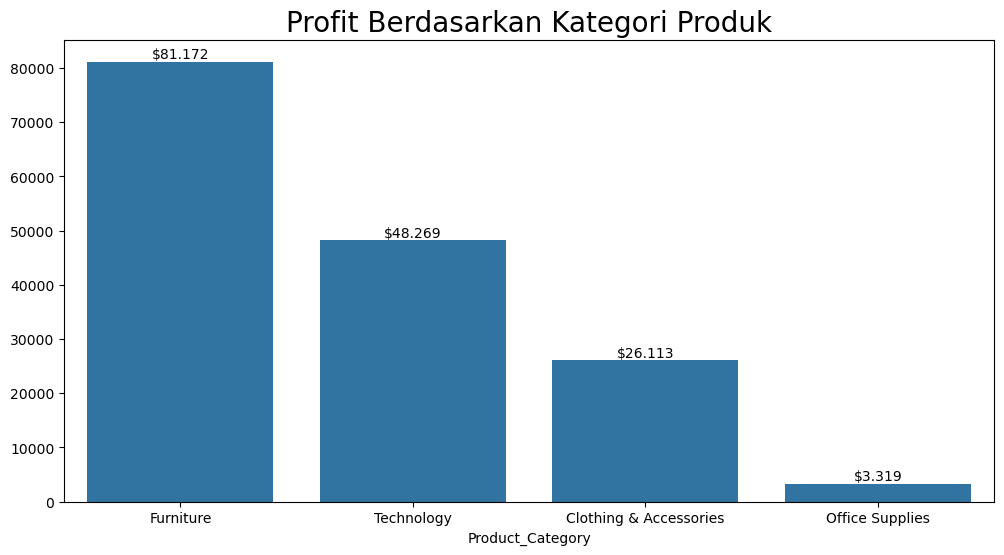

In [ ]:
# Inisiasi variabel untuk menyimpan hasil total Profit dari setiap kategori Produk
product_profit_margin = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)

# Inisasi besaran kanvas visualisasi
plt.figure(figsize=(12,6))

# Menyimpan grafik bar chart ke dalam variabel baru
ax = sns.barplot(x=product_profit_margin.index, y=product_profit_margin.values)

# Melakukan looping pada setiap bar 
for container in ax.containers :
    value_label = [f'${value:,.0f}'.replace(',', '.') for value in container.datavalues] # Melaukan formatting pada value label
    ax.bar_label(container, labels=value_label) # Menampilkan Value Label apda setiap Bar

plt.title('Profit Berdasarkan Kategori Produk', fontsize = 20) # Memberi judul Bar Chart
plt.show() # Tampilkan Bar Chart

### Insight

Kategori Furniture penghasil profit tertinggi dengan 81.172 Dollar, diikuti Technology 848.269 Dollar, lalu Clothing & Accessories 26.113 Dollar, dan terkecil adalah Office Supplies 3.319 Dollar

## 5. Statistik Deskriptif Penyebaran Profit

Mean: 79.43616
Median: 32.83
Std Dev: 137.57359317806728
Skewness: 3.924910412305914
Kurtosis: 21.450378037860034


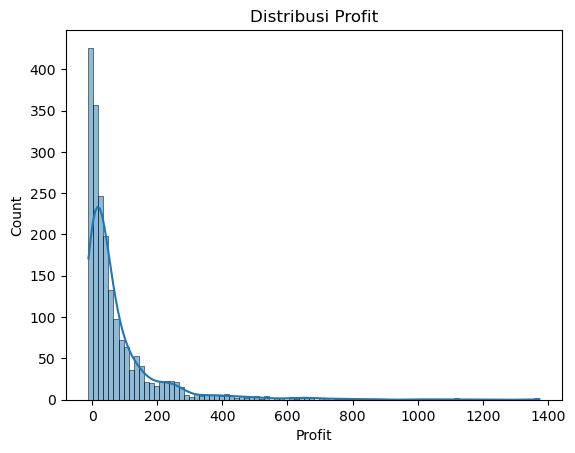

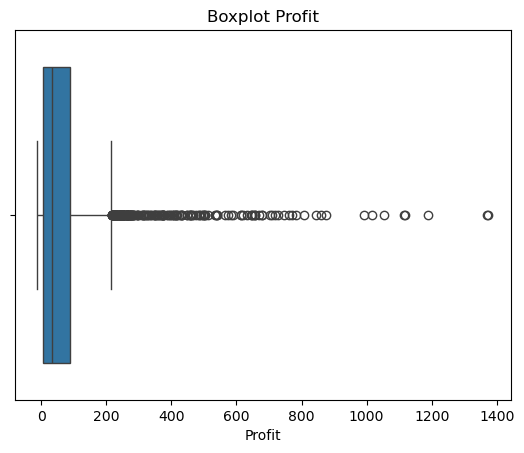

In [36]:
print("Mean:", df['Profit'].mean()) # Tampilkan rata-rata Profit
print("Median:", df['Profit'].median()) # Tampilkan Median Profit
print("Std Dev:", df['Profit'].std()) # Tampilkan standar deviasi profit
print("Skewness:", df['Profit'].skew()) # Tampilkan skewness profit
print("Kurtosis:", df['Profit'].kurtosis()) # Tampilkan Kurtosis Profit

sns.histplot(df['Profit'], kde=True) # Buat Histogram mengenai Profit dengan tambahan garis bantu
plt.title('Distribusi Profit') # Memberi Judul pada Chart
plt.show() # Tampilkan Chart

sns.boxplot(x=df['Profit']) # Membuat Box Chart menggunakan data Profit
plt.title('Boxplot Profit')# Memberi Judul pada Chart
plt.show()# Tampilkan Chart

### Insight

Mean < Median yang artinya banyak penjualan dengan profit kecil, namun bervariasi (ada juga yang besar walau sedikit). Skewness dan Kurtosis > 1 yang artinya distribusi profit condong ke kanan dan terdapat banyak outlier ekstrem

## 6. Pengaruh variabel numerikal terhadap Profit

Correlation total sales: 0.9792165360932548
P-value sales: 0.0
Correlation harga per unit: 0.6669027044029551
P-value unit: 1.4592555543585141e-257
Correlation kuantitas pemesanan: 0.5031553955152157
P-value quantity: 7.952087543821687e-129
Correlation shipping cost: 0.36383242432483087
P-value shipping: 1.2119471804577618e-63
Correlation diskon: -0.14133959995270484
P-value discount: 2.169403289137943e-10


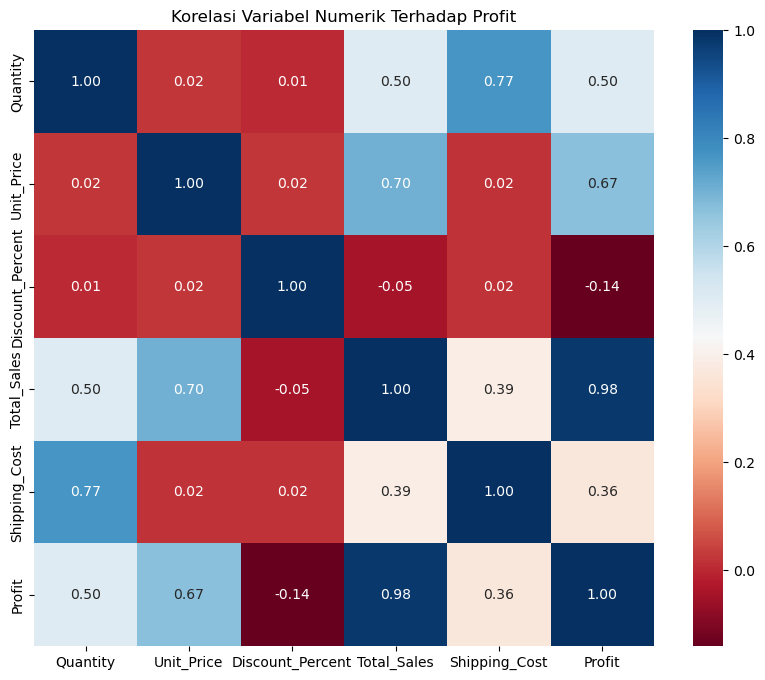

In [37]:
corr_sales, p_value_sales = pearsonr(df['Total_Sales'], df['Profit'])
corr_unit, p_value_unit = pearsonr(df['Unit_Price'], df['Profit'])
corr_quantity, p_value_quantity = pearsonr(df['Quantity'], df['Profit'])
corr_shipping, p_value_shipping = pearsonr(df['Shipping_Cost'], df['Profit'])
corr_discount, p_value_discount = pearsonr(df['Discount_Percent'], df['Profit'])

print("Correlation total sales:", corr_sales) # Menampilkan nilai korelasi
print("P-value sales:", p_value_sales) # Menampilkan nilai p-value

print("Correlation harga per unit:", corr_unit) # Menampilkan nilai korelasi
print("P-value unit:", p_value_unit) # Menampilkan nilai p-value

print("Correlation kuantitas pemesanan:", corr_quantity) # Menampilkan nilai korelasi
print("P-value quantity:", p_value_quantity) # Menampilkan nilai p-value

print("Correlation shipping cost:", corr_shipping) # Menampilkan nilai korelasi
print("P-value shipping:", p_value_shipping) # Menampilkan nilai p-value

print("Correlation diskon:", corr_discount) # Menampilkan nilai korelasi
print("P-value discount:", p_value_discount) # Men

# inisiasi variabel yang akan menampung hasil hitung korelasi terhadap semua kolom numerik
corr_var = df.select_dtypes(include=['float64', 'int64']).corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_var, annot=True, cmap='RdBu', fmt='.2f')
plt.title('Korelasi Variabel Numerik Terhadap Profit')
plt.show()

### Insight

Asumsi :
H0 = Tidak ada pengaruh terhadap profit
H1 = Ada pengaruh terhadap profit

jika dilihat, semua p-value variabel numerik terhadap profit adalah < 0.05 yang artinya semua variabel menolah H0 menjadikan semua variabel memiliki pengaruh terhadap profit walaupun ada yang korelasinya kecil.

# VI. Pengambilan Kesimpulan

## Kesimpulan

1. Profit dari penjualan tidak merata, banyak transaksi menghasilkan profit kecil dan sedikit yang menghasilkan profit tinggi.
2. Beberapa penjualan menghasilkan profit negatif.
3. Total Sales (Revenue) menjadi faktor utama yang mempengaruhi profit.
4. Perbedaan performa antar region, kategori produk, dan periode waktu yang cukup terlihat

## Rekomendasi

1. Perusahaan dapat fokus dalam produk-produk penghasil profit tertinggi.
2. Melakukan evaluasi strategi bisnis untuk kategori produk dan region dengan profit rendah.
3. Evaluasi strategi pemberian diskon
4. Membuat strategi yang akan memaksimalkan penjualan pada periode-periode tertentu yang menghasilkan profit terbesar